In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

In [3]:
import networkx as nx

# Predefined constants
n = 7  # Number of nodes
p = 0.6  # Probability of edge creation

# Generate an Erdős-Rényi network
G = nx.erdos_renyi_graph(n, p)

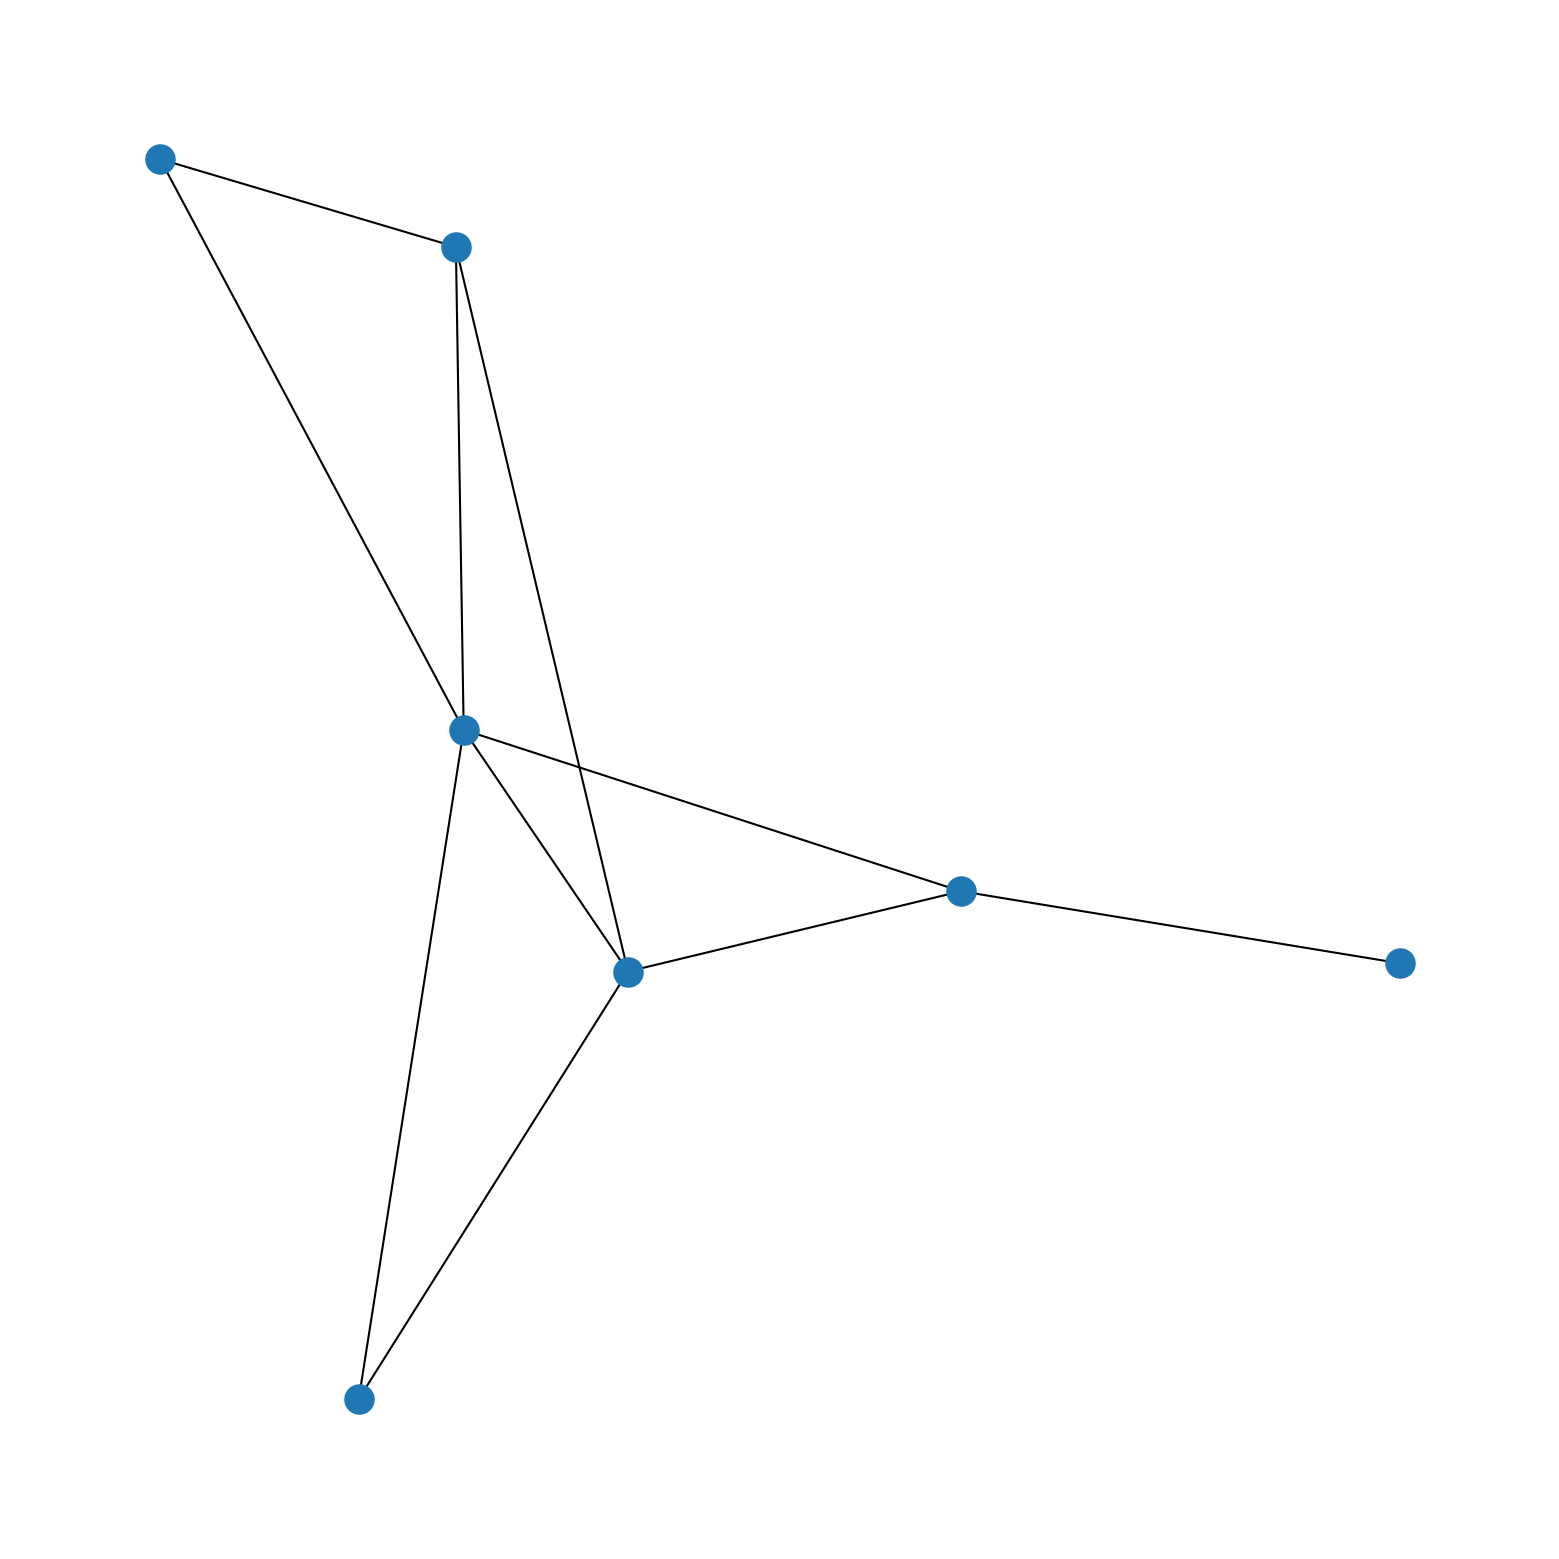

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5), dpi=150)  # Higher resolution plot
pos = nx.spring_layout(G)  # Use spring layout for positioning
nx.draw(G, pos, with_labels=False, node_size=40, width=0.5)  # No labels, thinner edges
plt.show()

In [5]:
available_games = [
    chicken_2player, 
    prisoners_dilemma_2player, 
    stag_hunt_2player, 
    harmony_2player
]

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = available_games[np.random.randint(len(available_games))]

In [6]:
# Sample a single node
sampled_node = np.random.choice(G.nodes)

# List the game for each edge connected to the sampled node
connected_edges = G.edges(sampled_node, data=True)
for edge in connected_edges:
    print(f"Edge: {edge[:2]}, Game: {edge[2]['game']}")

Edge: (6, 3), Game: tensor([[4., 1.],
        [3., 2.]])
Edge: (6, 5), Game: tensor([[4., 1.],
        [3., 2.]])


In [37]:
# # Initialisation ---------------------------------------------------------------
# game_transitions = [   
# #    ('PD', prisoners_dilemma_3player, 100),                                      # <--- Define game transitions here
#    ('Ch', chicken_2player, 500),
# #    ('SH', stag_hunt_3player_green, 500),
# #    ('SH', stag_hunt_3player_red, 500),
# #    ('SH', stag_hunt_3player_penalty, 500),
# #    ('Co', coordination_3player, 500),
# #    ('Ha', harmony_3player, 300),
# ]

T = 200  #sum([g[-1] for g in game_transitions])  # Total number of time steps
# num_players = game_transitions[0][1].ndim  # Number of agents
num_players = len(G.nodes)  # Number of players (nodes in the graph)
# num_actions = 2  #game_transitions[0][1].shape[0]  # Number of actions

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=30.,
        dynamic_precision=True,
        decay=0.8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
# Initialize agents with their respective game matrices
# agents = [
#     Agent(
#         id=i, 
#         game_matrix=game_transitions[0][1],
#         **agent_kwargs[i]
#     ) for i in range(num_players)
# ]

agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(NetworkAgent(id=node, game_matrices=adjacent_games, **agent_kwargs[node]))

# # Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# # Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 87
INFO:root:t=0/200
INFO:root:t=0/200
INFO:root:t=200/200 Simulation complete


In [38]:
variables_history

{'q_u': [[tensor([0.95, 0.05]),
   tensor([0.05, 0.95]),
   tensor([1.00, 0.00]),
   tensor([0.05, 0.95]),
   tensor([0.00, 1.00]),
   tensor([0.05, 0.95]),
   tensor([0.50, 0.50])],
  [tensor([0.93, 0.07]),
   tensor([0.04, 0.96]),
   tensor([1.00, 0.00]),
   tensor([0.04, 0.96]),
   tensor([0.00, 1.00]),
   tensor([0.04, 0.96]),
   tensor([0.50, 0.50])],
  [tensor([0.93, 0.07]),
   tensor([0.04, 0.96]),
   tensor([1.00, 0.00]),
   tensor([0.04, 0.96]),
   tensor([0.00, 1.00]),
   tensor([0.04, 0.96]),
   tensor([0.50, 0.50])],
  [tensor([0.93, 0.07]),
   tensor([0.04, 0.96]),
   tensor([1.00, 0.00]),
   tensor([0.04, 0.96]),
   tensor([0.00, 1.00]),
   tensor([0.04, 0.96]),
   tensor([0.50, 0.50])],
  [tensor([0.93, 0.07]),
   tensor([0.04, 0.96]),
   tensor([1.00, 0.00]),
   tensor([0.04, 0.96]),
   tensor([0.00, 1.00]),
   tensor([0.04, 0.96]),
   tensor([0.50, 0.50])],
  [tensor([0.93, 0.07]),
   tensor([0.04, 0.96]),
   tensor([1.00, 0.00]),
   tensor([0.04, 0.96]),
   tensor([0.